In [1]:
print("salut")

salut


Import des bibliothèques

In [16]:
import matplotlib.pyplot as plt
import os

Fonctions utilitaires pour naviguer dans la base :

In [ ]:
def choisir_image(dossier, nom_image):
    """
    Retourne le chemin complet de l'image si elle existe dans le dossier.
    """
    chemin_complet = os.path.join(dossier, nom_image)
    if os.path.isfile(chemin_complet):
        return chemin_complet
    else:
        print("Image non trouvée :", chemin_complet)
        return None

def lister_images(chemin_repertoire):
    """
    Affiche les noms des images contenues dans le dossier donné.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    try:
        fichiers = os.listdir(chemin_repertoire)
        images = [f for f in fichiers if f.lower().endswith(extensions)]
        for img in images:
            print(img)
    except FileNotFoundError:
        print("Dossier non trouvé :", chemin_repertoire)

def explorer_base(base):
    """
    Parcourt récursivement la base d'images, liste les sous-répertoires
    et affiche leur contenu en appelant lister_images().
    """
    for root, dirs, files in os.walk(base):
        print(f"Sous-répertoire : {root}")
        lister_images(root)
        print("-" * 40)

## choisir_images
chemin = choisir_image("./BD_images/Montres_37", "image371.jpg")
print(chemin)

## lister_images
lister_images("./BD_images/Montres_37")

## explorer_base
explorer_base("BD_images")

./BD_images/Montres_37/image371.jpg
image371.jpg
image372.jpg
image373.jpg
image374.jpg
image375.jpg
Sous-répertoire : BD_images
----------------------------------------
Sous-répertoire : BD_images/Ananas_8
image081.jpg
image082.jpg
image083.jpg
image084.jpg
image085.jpg
----------------------------------------
Sous-répertoire : BD_images/Arbres_30
image301.jpg
image302.jpg
image303.jpg
image304.jpg
image305.jpg
----------------------------------------
Sous-répertoire : BD_images/AuroresBoréales_ 5
image051.jpg
image052.jpg
image053.jpg
image054.jpg
image055.jpg
----------------------------------------
Sous-répertoire : BD_images/Avions_19
image191.jpg
image192.jpg
image193.jpg
image194.jpg
image195.jpg
----------------------------------------
Sous-répertoire : BD_images/Avocats_14
image141.jpg
image142.jpg
image143.jpg
image144.jpg
image145.jpg
----------------------------------------
Sous-répertoire : BD_images/Bananes_29
image291.jpg
image292.jpg
image293.jpg
image294.jpg
image295.j

Fonctions d'analyse statistique "sans ouvrir l'image"

40
['Ananas_8', 'Arbres_30', 'AuroresBoréales_ 5', 'Avions_19', 'Avocats_14', 'Bananes_29', 'Bateaux_4', 'Chats_13', 'Chevaux_20', 'Chiens_21', 'Citrons_3', 'ClefsHexagonales_34', 'Crocs_31', 'Deserts_11', 'Fleurs_6', 'Fraises_2', 'Glaces_38', 'ImagesSatellitaires_18', 'Lampes_40', 'Maisons_28', 'Masques_12', 'Mococos_27', 'Montagnes_9', 'Montres_37', 'moutons_36', 'Oranges_7', 'Pandas_25', 'Peepo_33', 'Pelotes_Laine_15', 'Photos_Sadek_17', 'Plages_10', 'Poissons_22', 'Suchis_16', 'Tiramisu_23', 'tomates_39', 'Tornades_32', 'Tortues_35', 'Vicking_26', 'Viennoiseries_24', 'Voitures_1']
200
200


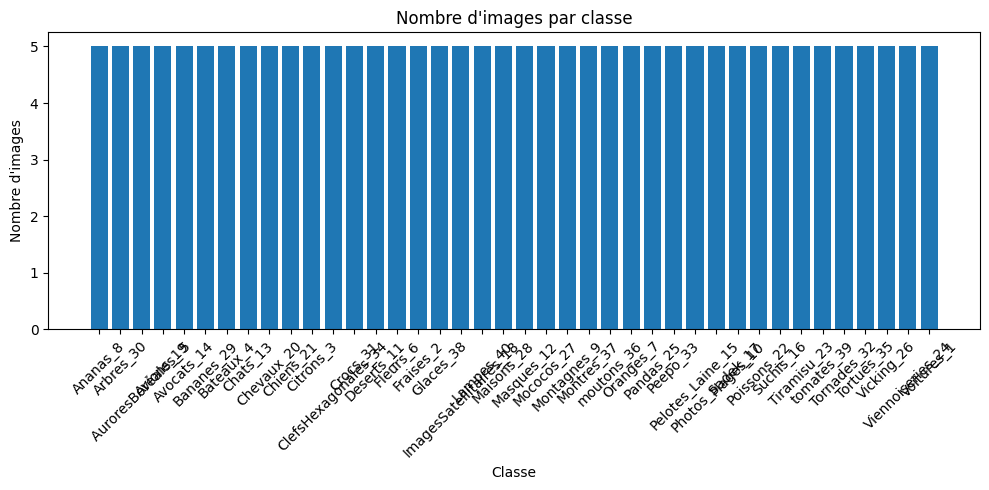

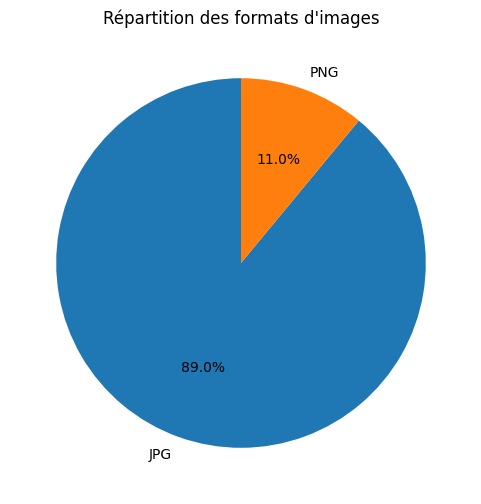

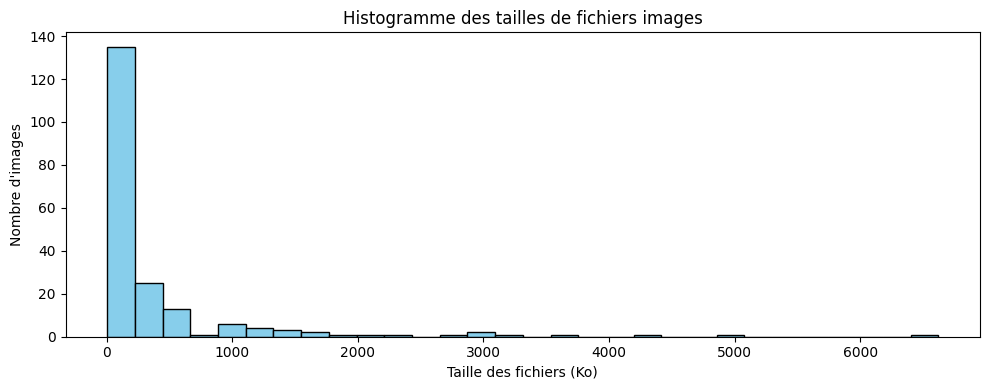

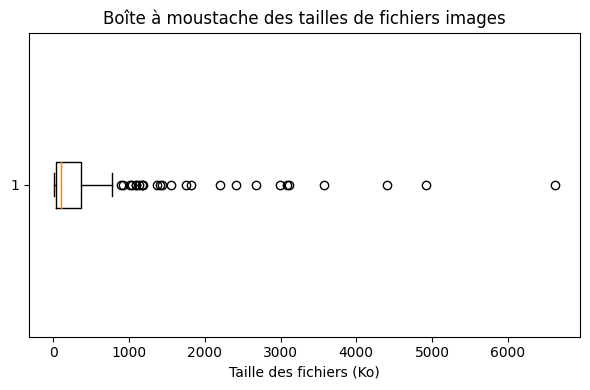

In [20]:
def compter_classes(base):
    """
    Retourne le nombre total de classes (sous-dossiers) et la liste des noms des classes.
    """
    try:
        classes = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
        return len(classes), classes
    except FileNotFoundError:
        print("Base non trouvée :", base)
        return 0, []
    
def compter_images(base):
    """
    Retourne le nombre total d'images de la base, toutes classes confondues.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    total = 0
    for root, dirs, files in os.walk(base):
        images = [f for f in files if f.lower().endswith(extensions)]
        total += len(images)
    return total

def verifier_cardinalite(base, nbi_cls=5):
    """
    Vérifie que chaque classe contient bien nbi_cls images.
    Affiche un message d’alerte si une classe est incomplète ou contient trop d’images.
    Produit un diagramme en bandes représentant le nombre d’images par classe.
    """
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    try:
        classes = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
        nb_images_par_classe = {}
        for classe in classes:
            dossier_classe = os.path.join(base, classe)
            fichiers = os.listdir(dossier_classe)
            images = [f for f in fichiers if f.lower().endswith(extensions)]
            nb_images = len(images)
            nb_images_par_classe[classe] = nb_images
            if nb_images < nbi_cls:
                print(f"ALERTE : Classe '{classe}' incomplète ({nb_images} images, attendu : {nbi_cls})")
            elif nb_images > nbi_cls:
                print(f"ALERTE : Classe '{classe}' trop d'images ({nb_images} images, attendu : {nbi_cls})")
        # Diagramme en bandes
        plt.figure(figsize=(10, 5))
        plt.bar(nb_images_par_classe.keys(), nb_images_par_classe.values())
        plt.xlabel("Classe")
        plt.ylabel("Nombre d'images")
        plt.title("Nombre d'images par classe")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except FileNotFoundError:
        print("Base non trouvée :", base)

def formats_images(base):
    """
    Calcule la répartition des formats d'images (JPEG, PNG, etc) dans la base
    et affiche les résultats sous forme d’un diagramme circulaire.
    """
    extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    formats_count = {ext.upper().replace('.', ''): 0 for ext in extensions}
    for root, dirs, files in os.walk(base):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in extensions:
                key = ext.upper().replace('.', '')
                formats_count[key] += 1
    # Retirer les formats non présents
    formats_count = {k: v for k, v in formats_count.items() if v > 0}
    if formats_count:
        plt.figure(figsize=(6, 6))
        plt.pie(formats_count.values(), labels=formats_count.keys(), autopct='%1.1f%%', startangle=90)
        plt.title("Répartition des formats d'images")
        plt.show()
    else:
        print("Aucune image trouvée dans la base.")

def taille_fichiers(base):
    """
    Calcule la répartition des tailles des images en Ko.
    Produit un histogramme des tailles de fichiers et une boîte à moustache pour mettre en évidence les extrêmes.
    """

    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
    tailles = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(extensions):
                chemin = os.path.join(root, f)
                taille_ko = os.path.getsize(chemin) / 1024  # taille en Ko
                tailles.append(taille_ko)

    if tailles:
        plt.figure(figsize=(10, 4))
        plt.hist(tailles, bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Taille des fichiers (Ko)")
        plt.ylabel("Nombre d'images")
        plt.title("Histogramme des tailles de fichiers images")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.boxplot(tailles, vert=False)
        plt.xlabel("Taille des fichiers (Ko)")
        plt.title("Boîte à moustache des tailles de fichiers images")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune image trouvée dans la base.")

## compter_classes
nb_classes, noms_classes = compter_classes("BD_images")
print(nb_classes)
print(noms_classes)

## compter_images
nb_images = compter_images("BD_images")
print(nb_images)

## verifier_cardinalite
verifier_cardinalite("BD_images", nbi_cls=5)

## formats_images
formats_images("BD_images")

## taille_fichiers
taille_fichiers("BD_images")



Fonctions d'analyse statistique "avec ouverture des images"